<a href="https://colab.research.google.com/github/addulamalerupareddy-gif/java_Practice/blob/main/statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [3]:
loan=pd.read_csv(r'/content/loandata.csv')
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001722,Male,Yes,0,Graduate,No,150,1800.0,135.0,360.0,1.0,Rural,N
1,LP002502,Female,Yes,2,Not Graduate,NaN,210,2917.0,98.0,360.0,1.0,Semiurban,Y
2,LP002949,Female,No,3+,Graduate,NaN,416,41667.0,350.0,180.0,NaN,Urban,N
3,LP002603,Female,No,0,Graduate,No,645,3683.0,113.0,480.0,1.0,Rural,Y
4,LP001644,NaN,Yes,0,Graduate,Yes,674,5296.0,168.0,360.0,1.0,Rural,Y


understand a set of variables influence

.loan apporal

.loan rejection

data cleaning

-optimize for max utility

-handling missing values

-handling

In [4]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


credit

In [11]:
loan.Credit_History.unique()

array([ 1., nan,  0.])

In [12]:
fill_ch=loan.Credit_History.mode()[0]
fill_ch

np.float64(1.0)

In [13]:
loan.Credit_History.value_counts()

,count
Credit_History,
1.0,475
0.0,89


In [14]:
loan.Credit_History.value_counts().sum()

np.int64(564)

self_employed

In [18]:
loan.Self_Employed.unique()

array(['No', nan, 'Yes'], dtype=object)

In [19]:
loan.Self_Employed.mode()[0]

'No'

loan Amount

In [20]:
loan.LoanAmount

,LoanAmount
0,135.0
1,98.0
2,350.0
3,113.0
4,168.0
...,...
609,120.0
610,600.0
611,700.0
612,490.0


<Axes: >

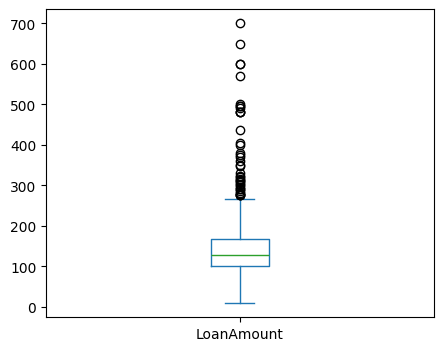

In [27]:
loan.LoanAmount.plot(kind='box',figsize=(5,4))

In [33]:
fill_ch=loan.LoanAmount.median()
fill_ch

128.0

In [32]:
loan.Dependents.head()

,Dependents
0,0
1,2
2,3+
3,0
4,0


In [34]:
loan.Dependents.unique()

array(['0', '2', '3+', '1', nan], dtype=object)

eventhough it is possible to count number of dependents during data collection researcher consider dependents as a categorial variable with categorial 0,1,2, and 3

In [35]:
fill_ch=loan.Dependents.mode()[0]
fill_ch

'0'

In [36]:
loan.Loan_Amount_Term.unique()

array([360., 180., 480., 120.,  nan, 300.,  60.,  84.,  36., 240.,  12.])

loan amount term is an option given by bank-CATEGORICAL


out of 614 observations there are very few unique values in loan_amount_term.if possible consider it as a CATERICAL VARIABLE

In [37]:
fill_ch=loan.Loan_Amount_Term.mode()[0]
fill_ch

np.float64(360.0)

gender

In [38]:
fill_g=loan.Gender.mode()[0]
fill_g

'Male'

married

In [39]:
fill_m=loan.Married.mode()[0]
fill_m

'Yes'

In [41]:
loan.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [46]:
#loan['Gender'].fillna('Male')
loan=loan.fillna({'Gender':fill_g, 'Married':fill_m, 'Dependents':fill_d,
       'Self_Employed':fill_se,  'LoanAmount':fill_la,
       'Loan_Amount_Term':fill_lt, 'Credit_History':fill_ch})
loan.isna().sum()

NameError: name 'fill_d' is not defined

In [47]:
loan.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
609,False
610,False
611,False
612,False


**Detect outliers**

single var-IQR,BOX PLOT


multiple Variable-meurist(thumb rule),isolation forest,lof,knn-'pyod library'-ML

**heuistic**

-similar to IQR Method

-the value in the percentiles 0 to 25 and 75 to 100 are discarded.Because in the percentiles 0 to 25 and 75 to 100 there is high chance for outliers

-evaluate data between 0 to 25 and 75 to 100 fo any sudden jump in the values

.if exist -presence of outliers

In [51]:
loan.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [52]:
loan.describe(percentiles=[0.05,0.10,0.15,0.20])

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
5%,1897.550000,0.000000,56.000000,180.00000,0.000000
10%,2216.100000,0.000000,71.000000,294.00000,0.000000
15%,2478.700000,0.000000,84.650000,360.00000,0.000000
20%,2605.400000,0.000000,95.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [53]:
loan.describe(percentiles=[0.75,0.80,0.85,0.90,0.95])

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
80%,6252.400000,2535.000000,182.000000,360.00000,1.000000
85%,7578.250000,3053.650000,192.000000,360.00000,1.000000
90%,9459.900000,3782.200000,235.800000,360.00000,1.000000
95%,14583.000000,4997.400000,297.800000,360.00000,1.000000
